# 08. Truck Performance

## Business Question

Do truck-level factors (capacity fit, age) explain the route and cargo performance issues identified in prior notebooks, and is profitability concentrated across trucks the way it is across clients?

### Methodology Note

In this dataset, `driver_id` is not consistently paired with `truck_id` across trips (unlike the intended real-world 1:1 driver-truck assignment) - this is a data generation limitation, documented here rather than corrected. As a result, this analysis treats truck-level questions only, using static truck attributes (`truck_capacity_tons`, `truck_year`, `truck_brand`) that don't depend on who was driving, and does not attempt to attribute performance to driver-truck combinations.

This notebook is intentionally lighter in scope than `05_client_profitability.ipynb` or `07_route_analysis.ipynb`: truck-level data here does not support the same depth of causal analysis as client- or route-level data. It follows two specific threads already opened by prior notebooks rather than a generic truck ranking: (1) the capacity-matching question flagged in `07_route_analysis.ipynb` for Подільськ-Чорноморськ, and (2) the open question from `03_business_overview_summary.md` on whether profit concentrates across trucks the way revenue does not.

Fuel efficiency (L or UAH per ton-km) is checked twice in this notebook, but only as a mechanism explaining another pattern (capacity fit, truck age) - not as a standalone ranking, consistent with the project's approach of testing mechanisms rather than stopping at correlation.

In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 5)

In [2]:
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True,
    future=True
)

try:
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
    print("Successfully connected to MySQL.")
except Exception as e:
    print(f"Connection failed:\n{e}")

Successfully connected to MySQL.


### Data Preparation

In [3]:
trips = pd.read_sql(
    text("SELECT * FROM trip_analytical_dataset"),
    engine,
    parse_dates=["date_departure", "date_arrival"]
)

truck_downtime = pd.read_sql(
    text("SELECT * FROM truck_downtime"),
    engine,
    parse_dates=["date_from", "date_to"]
)

print(f"Trips loaded: {len(trips):,}")
print(f"Truck downtime records loaded: {len(truck_downtime):,}")
print(f"Downtime reason values: {truck_downtime['reason'].unique()}")

Trips loaded: 4,925
Truck downtime records loaded: 34
Downtime reason values: ['scheduled_maintenance' 'breakdown']


## Dataset Validation

In [4]:
trips_2024 = trips[trips["date_departure"].dt.year == 2024]
valid_2024 = trips_2024.dropna(subset=["revenue_uah", "gross_profit_uah", "trip_distance_km"])

print(f"Total trips: {len(trips):,}")
print(f"Trips in 2024: {len(trips_2024):,}")
print(f"Valid 2024 trips: {len(valid_2024):,}")
print(f"Unique trucks: {valid_2024['truck_id'].nunique()}")
print(f"Trucks with downtime records: {truck_downtime['truck_id'].nunique()}")

driver_truck_check = trips.groupby("driver_id")["truck_id"].nunique()
print(f"\nDrivers paired with more than one truck: {(driver_truck_check > 1).sum()} of {len(driver_truck_check)}")

Total trips: 4,925
Trips in 2024: 1,422
Valid 2024 trips: 1,362
Unique trucks: 12
Trucks with downtime records: 12

Drivers paired with more than one truck: 12 of 12


**Confirmed:** drivers are not consistently paired with a single truck in this dataset - see Methodology Note above. Truck-level attributes only are used going forward.

## 1. Profit Concentration by Truck

Screening step: is profit concentrated across trucks the way it is across clients (`05_client_profitability.ipynb`), or evenly spread as revenue already was found to be (`03_business_overview_summary.md`)?

In [5]:
truck_profit = (
    valid_2024
    .groupby(["truck_id", "truck_brand", "truck_model"])
    .agg(
        trip_count=("trip_id", "count"),
        revenue_uah=("revenue_uah", "sum"),
        gross_profit_uah=("gross_profit_uah", "sum"),
    )
)
truck_profit["gross_margin_pct"] = (
    truck_profit["gross_profit_uah"] / truck_profit["revenue_uah"] * 100
).round(1)

truck_profit = truck_profit.reset_index().sort_values("gross_profit_uah", ascending=False)
truck_profit

,truck_id,truck_brand,truck_model,trip_count,revenue_uah,gross_profit_uah,gross_margin_pct
3,TRK-04,Volvo,FH 460,151,1.962636e+06,1.061815e+06,54.1
7,TRK-08,DAF,XF 480,141,1.888668e+06,1.059045e+06,56.1
5,TRK-06,MAN,TGX 18.440,144,1.966374e+06,1.023259e+06,52.0
10,TRK-11,MAN,TGX 18.480,142,1.790077e+06,9.793854e+05,54.7
8,TRK-09,Volvo,FH 500,137,1.699863e+06,9.135725e+05,53.7
4,TRK-05,Scania,R450,114,1.319444e+06,7.699706e+05,58.4
9,TRK-10,Scania,G450,99,1.326774e+06,7.683446e+05,57.9
11,TRK-12,Mercedes,Actros 1848,94,1.322523e+06,7.557178e+05,57.1
6,TRK-07,Mercedes,Actros 1845,92,1.225807e+06,7.072999e+05,57.7
2,TRK-03,DAF,CF 85,107,1.170562e+06,5.735707e+05,49.0


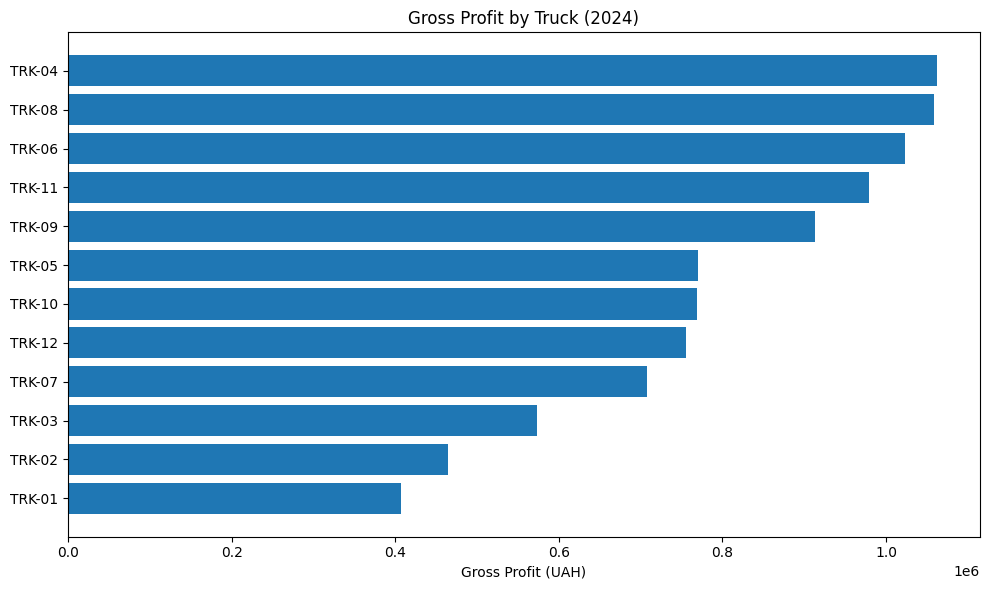

In [6]:
truck_profit_sorted = truck_profit.sort_values("gross_profit_uah", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(truck_profit_sorted["truck_id"], truck_profit_sorted["gross_profit_uah"], color="tab:blue")
ax.set_xlabel("Gross Profit (UAH)")
ax.set_title("Gross Profit by Truck (2024)")
plt.tight_layout()
plt.show()

In [7]:
top5_profit_share = (
    truck_profit.sort_values("gross_profit_uah", ascending=False)
    .head(5)["gross_profit_uah"].sum()
    / truck_profit["gross_profit_uah"].sum() * 100
)

print(f"Top 5 trucks' share of total profit: {top5_profit_share:.1f}%")
print(f"Number of trucks: {len(truck_profit)}")

Top 5 trucks' share of total profit: 53.1%
Number of trucks: 12


#### Key Finding

Profit shows some spread across the fleet (49.0%-58.4% margin, TRK-03 lowest to TRK-05 highest), but nowhere near the concentration seen at the client level: the top 5 trucks by profit account for 53.1% of total gross profit, compared to 84.4% for the top 5 clients in `05_client_profitability.ipynb`. This confirms the open question from `03_business_overview_summary.md` - profit, like revenue, is roughly evenly distributed across the fleet, not concentrated in a few trucks. Truck-level effects, if any, are second-order compared to client- or route-level effects.

## 2. Truck Age vs Profitability

Checking whether older trucks (`truck_year`) show systematically lower margin - and if so, whether fuel efficiency is the mechanism (older engines -> worse fuel efficiency -> higher fuel cost per ton-km -> compressed margin), the same causal-chain approach used in Section 3 and throughout `06_fuel_cost_impact.ipynb` / `07_route_analysis.ipynb`.

In [8]:
truck_age_profit = (
    valid_2024
    .groupby(["truck_id", "truck_year"])
    .agg(
        trip_count=("trip_id", "count"),
        revenue_uah=("revenue_uah", "sum"),
        gross_profit_uah=("gross_profit_uah", "sum"),
    )
)
truck_age_profit["gross_margin_pct"] = (
    truck_age_profit["gross_profit_uah"] / truck_age_profit["revenue_uah"] * 100
).round(1)

truck_age_profit = truck_age_profit.reset_index().sort_values("truck_year")
truck_age_profit

,truck_id,truck_year,trip_count,revenue_uah,gross_profit_uah,gross_margin_pct
0,TRK-01,2015,78,7.874896e+05,4.066949e+05,51.6
1,TRK-02,2016,63,8.222824e+05,4.647900e+05,56.5
2,TRK-03,2017,107,1.170562e+06,5.735707e+05,49.0
3,TRK-04,2018,151,1.962636e+06,1.061815e+06,54.1
4,TRK-05,2018,114,1.319444e+06,7.699706e+05,58.4
5,TRK-06,2019,144,1.966374e+06,1.023259e+06,52.0
6,TRK-07,2019,92,1.225807e+06,7.072999e+05,57.7
7,TRK-08,2020,141,1.888668e+06,1.059045e+06,56.1
8,TRK-09,2020,137,1.699863e+06,9.135725e+05,53.7
9,TRK-10,2021,99,1.326774e+06,7.683446e+05,57.9


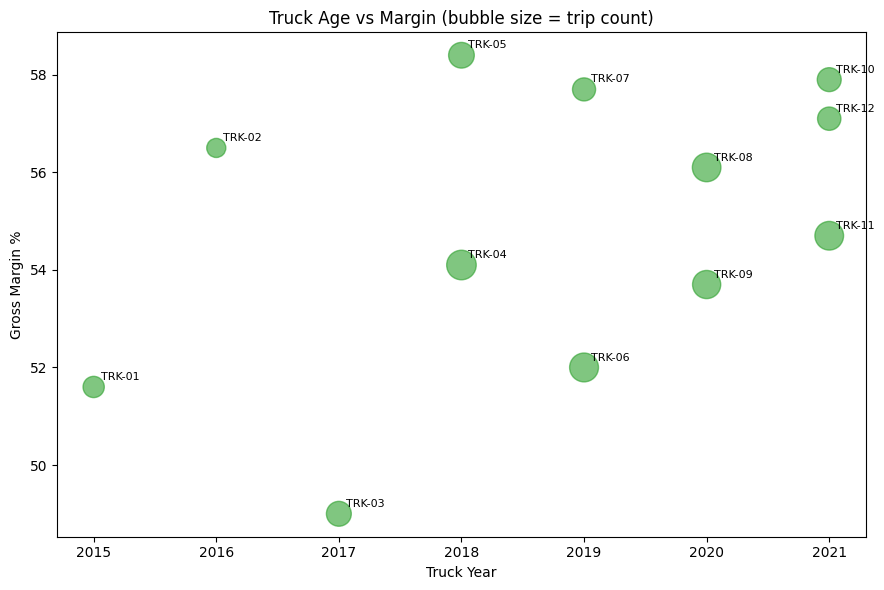

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(truck_age_profit["truck_year"], truck_age_profit["gross_margin_pct"], s=truck_age_profit["trip_count"] * 3, alpha=0.6, color="tab:green")
for _, row in truck_age_profit.iterrows():
    ax.annotate(row["truck_id"], (row["truck_year"], row["gross_margin_pct"]), fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Truck Year")
ax.set_ylabel("Gross Margin %")
ax.set_title("Truck Age vs Margin (bubble size = trip count)")
plt.tight_layout()
plt.show()

#### Key Finding

No clear or consistent relationship between truck year and margin: margin varies widely within every age group (2018 alone spans 54.1%-58.4%), and the fleet's single lowest-margin truck (TRK-03, 49.0%) is a 2017 model, not the oldest (TRK-01, 2015, sits at a middling 51.6%). Newer trucks (2020-2021) average slightly higher margin (~55-58%) than the two oldest (2015, 2017: ~50%), but the pattern isn't monotonic and is driven mainly by these two specific trucks, not a fleet-wide age gradient. Truck age is not a strong or consistent driver of profitability here - a valid, honest finding rather than a gap.

In [10]:
# Mechanism check: fuel efficiency by truck age, only if Section 4's finding warrants it
truck_fuel_efficiency = (
    valid_2024
    .assign(fuel_cost_per_tonkm=lambda d: d["fuel_cost_uah"] / (d["trip_distance_km"] * d["cargo_tons_actual"]))
    .groupby(["truck_id", "truck_year"])["fuel_cost_per_tonkm"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values("truck_year")
)
truck_fuel_efficiency

,truck_id,truck_year,fuel_cost_per_tonkm
0,TRK-01,2015,1.10
1,TRK-02,2016,0.96
2,TRK-03,2017,1.12
3,TRK-04,2018,1.00
4,TRK-05,2018,0.92
5,TRK-06,2019,1.03
6,TRK-07,2019,0.92
7,TRK-08,2020,0.96
8,TRK-09,2020,0.99
9,TRK-10,2021,0.92


#### Key Finding

Fuel cost per ton-km is similarly inconsistent by age: the two oldest trucks (TRK-01, 2015: 1.10; TRK-03, 2017: 1.12) do show the highest fuel cost in the fleet, but 2018-2021 trucks don't follow a clean downward gradient (e.g. TRK-06, 2019: 1.03, close to the oldest trucks; TRK-10, 2021: 0.92, among the best). This weakly supports a fuel-efficiency link for just the two oldest trucks, but doesn't hold as a fleet-wide mechanism - consistent with the age-margin finding above.

## 3. Truck-Route Correlation - Are Inefficient Trucks Concentrated on Inefficient Routes?

`07_route_analysis.ipynb` already established which routes are structurally low-margin (port routes, especially Подільськ-Чорноморськ). Rather than re-confirming that finding, this checks a different question: do the lowest-margin trucks (from Section 1) happen to operate on the lowest-margin routes, or are trucks distributed independently of route quality? If the correlation is strong, truck assignment may be compounding route-level problems; if weak, the two are independent issues.

In [11]:
bottom_trucks = truck_profit.sort_values("gross_margin_pct").head(4)["truck_id"]

truck_route_mix = (
    valid_2024[valid_2024["truck_id"].isin(bottom_trucks)]
    .groupby(["truck_id", "origin_city", "destination_city"])
    .agg(
        trip_count=("trip_id", "count"),
        route_margin_pct=("gross_margin_pct", "mean"),
    )
    .round(1)
    .reset_index()
    .sort_values(["truck_id", "trip_count"], ascending=[True, False])
)
truck_route_mix

,truck_id,origin_city,destination_city,trip_count,route_margin_pct
3,TRK-01,Кропивницький,Дніпро,11,58.1
4,TRK-01,Миколаїв,Одеса,11,47.6
0,TRK-01,Вінниця,Жмеринка,10,45.0
6,TRK-01,Полтава,Чорноморськ,10,48.1
9,TRK-01,Чернігів,Київ,9,52.1
8,TRK-01,Черкаси,Кременчук,7,58.2
1,TRK-01,Вінниця,Київ,6,52.9
5,TRK-01,Подільськ,Чорноморськ,6,38.8
2,TRK-01,Дніпро,Одеса,4,55.0
7,TRK-01,Хмельницький,Тернопіль,4,54.1


In [12]:
bottom_truck_non_port_margin = (
    valid_2024[
        (valid_2024["truck_id"].isin(bottom_trucks)) &
        ~((valid_2024["origin_city"] == "Подільськ") & (valid_2024["destination_city"] == "Чорноморськ"))
    ]
    .groupby("truck_id")["gross_margin_pct"]
    .mean()
    .round(1)
)
print(bottom_truck_non_port_margin)

truck_id
TRK-01    51.7
TRK-03    51.0
TRK-06    53.2
TRK-09    54.7
Name: gross_margin_pct, dtype: float64


#### Key Finding

The four bottom-margin trucks (TRK-01, TRK-03, TRK-06, TRK-09) are not concentrated on a small subset of routes - each serves all 10 routes, ruling out the simplest confound (one bad truck inflating one route's reputation). On Подільськ-Чорноморськ specifically, three of these four trucks show margin well below even that route's already-low 2024 average (43.8%, `07_route_analysis.ipynb`): TRK-01 38.8%, TRK-03 35.8%, TRK-09 37.0%; only TRK-06 (44.6%) sits close to baseline.

A direct test confirms the route, not the truck, is the primary driver: on their other 9 routes, these same four trucks average 51.0-54.7% margin - a 12-18 pp jump for TRK-01, TRK-03 and TRK-09. That's a far larger swing than these trucks' own tendency to run below the fleet average (54.9%) elsewhere (TRK-01 and TRK-03 sit 3-4 pp below fleet average even off this route, consistent with being the fleet's two lowest-margin trucks overall - `truck_profit`, Section 1). So a mild truck-level tendency exists and doesn't fully disappear, but it's small next to the route's effect: Подільськ-Чорноморськ's structural fuel-cost/load-factor issue (established in `07_route_analysis.ipynb`) dominates whichever truck is assigned to it. The port-route figures themselves are still based on 6-7 trips per truck, so treat the exact values with some caution - but the direction and size of the swing across two independent, much larger samples make route-level causation the clearly more likely explanation.

## 4. Truck Downtime

Downtime frequency and duration by truck and reason, for 2024. Descriptive only - this section documents the pattern without attempting causal claims about why specific trucks have more downtime.

In [13]:
downtime_2024 = truck_downtime[truck_downtime["date_from"].dt.year == 2024].copy()
downtime_2024["downtime_days"] = (downtime_2024["date_to"] - downtime_2024["date_from"]).dt.days

downtime_summary = (
    downtime_2024
    .groupby("truck_id")
    .agg(
        downtime_events=("downtime_id", "count"),
        total_downtime_days=("downtime_days", "sum"),
    )
    .sort_values("total_downtime_days", ascending=False)
)
downtime_summary.reset_index()

,truck_id,downtime_events,total_downtime_days
0,TRK-01,2,85
1,TRK-02,2,78
2,TRK-12,2,77
3,TRK-05,2,58
4,TRK-04,2,54
5,TRK-07,1,38
6,TRK-08,1,37
7,TRK-11,1,29
8,TRK-10,1,23
9,TRK-03,1,12


In [14]:
downtime_by_reason = (
    downtime_2024
    .groupby("reason")
    .agg(
        events=("downtime_id", "count"),
        total_days=("downtime_days", "sum"),
        avg_days=("downtime_days", "mean"),
    )
    .round(1)
    .sort_values("total_days", ascending=False)
)
downtime_by_reason.reset_index()

,reason,events,total_days,avg_days
0,breakdown,10,339,33.9
1,scheduled_maintenance,5,152,30.4


In [15]:
downtime_route_check = (
    truck_profit[["truck_id", "gross_margin_pct"]]
    .rename(columns={"gross_margin_pct": "truck_margin_pct"})
    .merge(
        downtime_summary.reset_index()[["truck_id", "total_downtime_days"]],
        on="truck_id",
        how="left"
    )
    .fillna({"total_downtime_days": 0})
    .sort_values("total_downtime_days", ascending=False)
)
downtime_route_check

,truck_id,truck_margin_pct,total_downtime_days
11,TRK-01,51.6,85.0
10,TRK-02,56.5,78.0
7,TRK-12,57.1,77.0
5,TRK-05,58.4,58.0
0,TRK-04,54.1,54.0
8,TRK-07,57.7,38.0
1,TRK-08,56.1,37.0
3,TRK-11,54.7,29.0
6,TRK-10,57.9,23.0
9,TRK-03,49.0,12.0


In [16]:
top5_downtime_share = (
    downtime_summary.sort_values("total_downtime_days", ascending=False)
    .head(5)["total_downtime_days"].sum()
    / downtime_summary["total_downtime_days"].sum() * 100
)
print(f"Top 5 trucks' share of total downtime days: {top5_downtime_share:.1f}%")

Top 5 trucks' share of total downtime days: 71.7%


#### Key Finding

Total downtime in 2024: 491 days across 15 events (339 days / 10 events from breakdowns, 152 days / 5 events from scheduled maintenance) - breakdowns account for more total downtime and are more frequent, though not dramatically longer per event (33.9 vs 30.4 avg days). Downtime concentrates in about half the fleet: the top 5 trucks by downtime account for 71.7% of all downtime days, while TRK-06 and TRK-09 show none.

There's no consistent link between downtime and margin: TRK-01 (highest downtime, 85 days) does show the fleet's second-lowest margin (51.6%), but TRK-02 and TRK-12 (also high downtime, 78 and 77 days) show some of the fleet's highest margins (56.5%, 57.1%) - directly contradicting a simple downtime-hurts-margin story. Of the four bottom-margin trucks flagged in Section 3, only TRK-01 has notable downtime; TRK-03 has minimal (12 days) and TRK-06/TRK-09 have none - so downtime does not explain why these four trucks are bottom-margin. This is a valid null finding: downtime and margin appear independent in this dataset.

## Key Findings

- Profit is roughly evenly distributed across the fleet (49.0-58.4% margin across 12 trucks), unlike the sharp concentration seen at the client level - the top 5 trucks account for 53.1% of profit vs. 84.4% for the top 5 clients in `05_client_profitability.ipynb`. This confirms the open question from `03_business_overview_summary.md`: truck-level effects are second-order compared to client- or route-level effects.
- Truck age shows no clear or consistent relationship with margin or fuel efficiency. The fleet's lowest-margin truck (TRK-03, 49.0%) is a 2017 model, not the oldest; only the two oldest trucks (2015, 2017) show elevated fuel cost per ton-km (1.10, 1.12), and this doesn't extend to a fleet-wide age gradient. Age is not a meaningful driver here - a valid, honest finding rather than a gap.
- The four bottom-margin trucks are not concentrated on a small subset of routes - each serves all 10 routes, ruling out the simplest confound (one bad truck inflating one route's reputation). A direct test confirms Подільськ-Чорноморськ, not the trucks themselves, drives their worst outcomes: these same four trucks recover to 51.0-54.7% margin on their other routes - a 12-18 pp jump for three of them - confirming the route's structural fuel-cost/load-factor issue (`07_route_analysis.ipynb`) dominates whichever truck is assigned to it, though the port-route observations themselves remain a small sample (6-7 trips per truck).
- Downtime (491 days total in 2024, concentrated in half the fleet - top 5 trucks account for 71.7% of all downtime days) shows no consistent relationship with margin: the truck with the most downtime (TRK-01, 85 days) does have low margin (51.6%), but two other high-downtime trucks (TRK-02, TRK-12) have some of the fleet's highest margins (56.5%, 57.1%). Downtime does not explain why the four bottom-margin trucks underperform - three of them have minimal or zero recorded downtime.

## Business Recommendations

- Skip fleet-wide truck replacement or age-based capex - truck age isn't a consistent driver of margin or fuel efficiency here; only the two oldest trucks (TRK-01, TRK-03) show a fuel-efficiency signal worth monitoring individually, not a fleet-wide pattern.
- Don't try to fix Подільськ-Чорноморськ's low margin by reassigning trucks - the route's structural fuel-cost/load-factor problem (established in `07_route_analysis.ipynb`) affects any truck placed on it; the four bottom-margin trucks' own margin recovers to 51-55% as soon as they're off this route. Any fix needs to happen at the route/cargo level (tariff or fuel surcharge renegotiation for wheat cargo), not through truck-level assignment changes.
- Track downtime and margin as separate operational issues, not a shared metric - two of the highest-downtime trucks (TRK-02, TRK-12) are among the fleet's most profitable, and the bottom-margin trucks identified above mostly have low or no downtime.
- Deprioritize truck-level intervention relative to the client- and route-level fixes already recommended in `05_client_profitability.ipynb` and `07_route_analysis.ipynb` - profit is evenly spread across the fleet, and this notebook found no comparable structural risk at the truck level.

## Save Dataset

In [17]:
output_path = Path("../data/processed/truck_performance.csv")
truck_profit.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

Saved: ../data/processed/truck_performance.csv


In [18]:
truck_profit.to_sql("truck_performance", engine, if_exists="replace", index=False)
print("truck_performance written to MySQL.")

truck_performance written to MySQL.


## Summary

Truck-level analysis found no dominant structural pattern comparable to the client- or route-level findings in prior notebooks: profit is roughly evenly distributed across the fleet, and truck age is not a consistent driver of margin or fuel efficiency. The one confirmed causal link is on Подільськ-Чорноморськ: three of the four bottom-margin trucks underperform even that route's already-low baseline, but recover to near-normal margin (51.0-54.7%) as soon as they're on any other route - confirming that the route's structural fuel-cost/load-factor issue (`07_route_analysis.ipynb`), not truck assignment, drives the shortfall, though the port-route observations themselves are still based on 6-7 trips per truck. Downtime, while real (491 days in 2024, concentrated in about half the fleet), does not correlate with margin and should be tracked separately.

Output: `truck_performance` (MySQL table and `data/processed/truck_performance.csv`). This concludes the four business-question notebooks (05-08); remaining work is the corresponding Tableau dashboard tab.